# GRPO với ràng buộc tỷ lệ đúng → sai — seed 42

Lượt được giữ: `general_math_window_1024_seed42_deadline_oct6`. Model Qwen2.5-1.5B-Instruct, bốn chủ đề toán, 128 bước/bài train mỗi nhánh, 512 anchor ứng viên (153 bài ban đầu đúng), 160 validation và 640 test. Giới hạn sinh 1024 token; loader train/evaluate đồng nhất precision.

So sánh GRPO với GRPO + ràng buộc mềm theo chủ đề. Lambda cập nhật sau mỗi 32 bước, dùng ở cửa sổ kế tiếp; loss gồm GRPO loss cộng lambda nhân gold-solution loss của anchor.

Kết quả: GRPO đúng 199/640, ràng buộc đúng 200/640. Đúng→sai giảm 20→17 trên 194 bài base-correct; sai→đúng giảm 25→23. Train 3,32→3,89 giờ; cả pipeline 15,85 giờ. Khoảng bootstrap 95% của chênh lệch flip vẫn chứa 0: tín hiệu nhỏ, chưa đủ kết luận tốt hơn ổn định.

**Hạn chế:** một seed, verifier chỉ hỗ trợ đáp án nguyên; test đã được xem trước khi chọn quay về feedback cửa sổ. Đây là đánh giá thăm dò hậu nghiệm, không phải xác nhận độc lập. Bài bị cắt vẫn thuộc metric chính.


,method,test_macro_accuracy,correct_to_wrong,initially_correct_test,correct_to_wrong_rate,wrong_to_correct,test_capped_rate,train_seconds
0,initial,0.303125,0,194,0.000000,0,0.025000,0.000000
1,grpo,0.310937,20,194,0.103093,25,0.031250,11949.702369
2,flip_constrained_grpo,0.312500,17,194,0.087629,23,0.034375,14005.912119


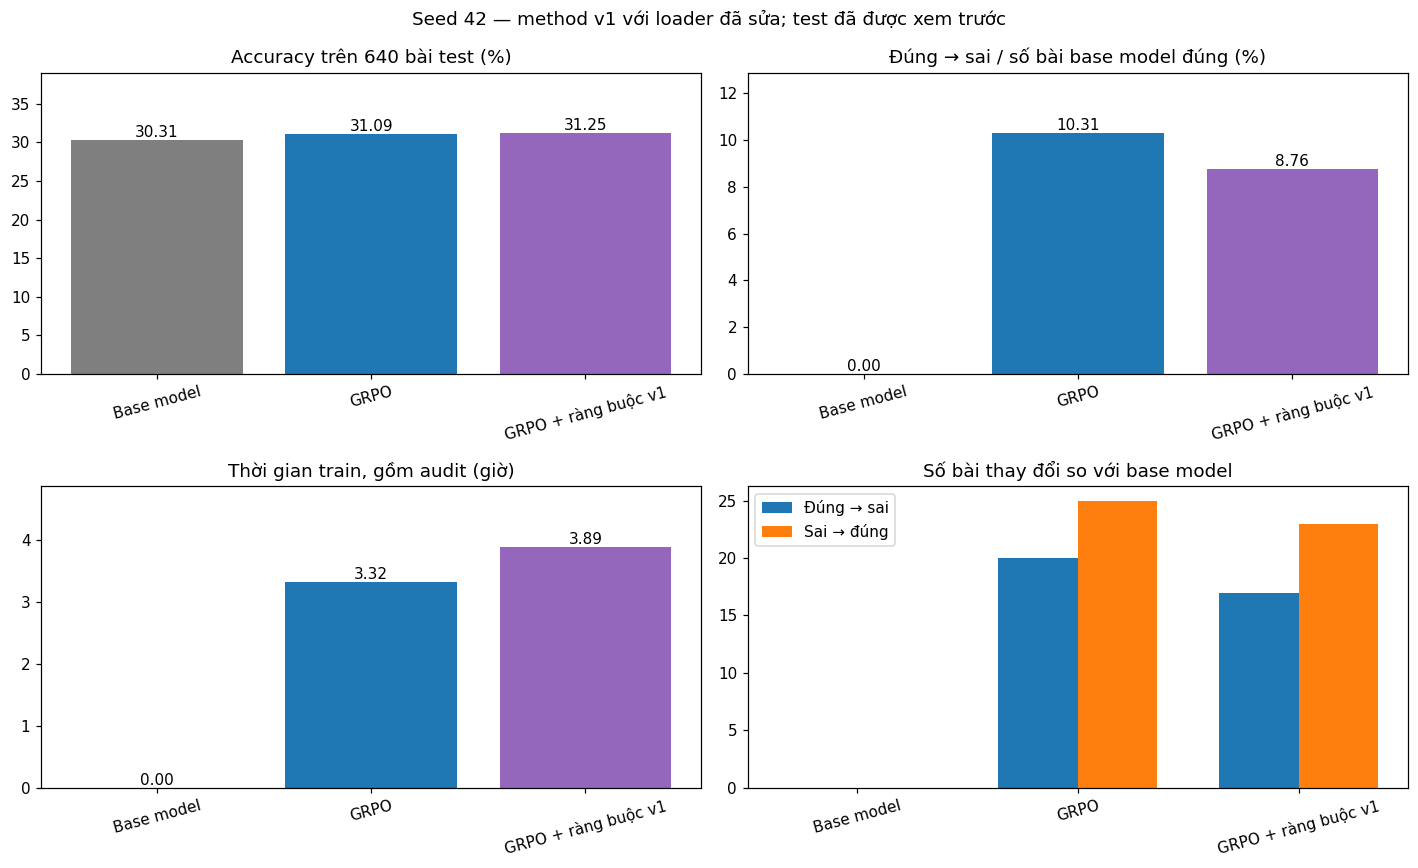

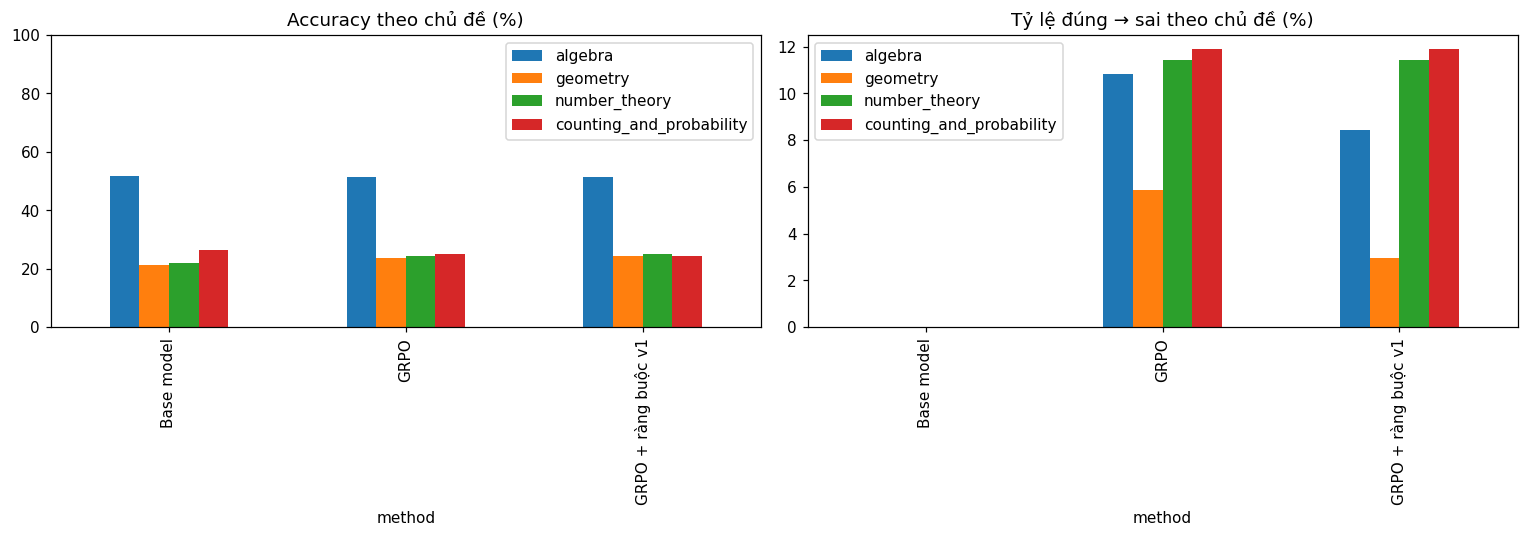

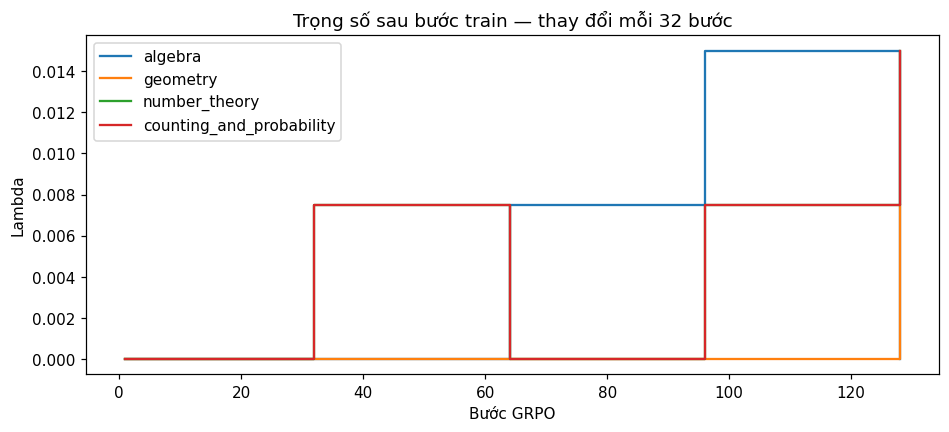

Trọng số ghi sau bước 32 chỉ được dùng từ bước 33; cập nhật ở bước 128 không còn bước train để dùng.


,scope,seed,completed_seeds,unique_test_questions,initially_correct_unique,accuracy_difference_pp,accuracy_ci_low_pp,accuracy_ci_high_pp,flip_rate_difference_pp,flip_ci_low_pp,flip_ci_high_pp,bootstrap_resamples
0,all_topics,all,42,640,194,0.15625,-0.78125,1.09375,-1.546392,-3.940887,0.531915,2000
2,algebra,all,42,160,83,0.00000,-2.50000,2.50000,-2.409639,-6.412338,0.000000,2000
4,geometry,all,42,160,34,0.62500,0.00000,1.87500,-2.941176,-9.375000,0.000000,2000
6,number_theory,all,42,160,35,0.62500,0.00000,1.87500,0.000000,0.000000,0.000000,2000
8,counting_and_probability,all,42,160,42,-0.62500,-3.12500,1.25000,0.000000,-6.521739,6.976744,2000


Chênh lệch = ràng buộc trừ GRPO. Accuracy dương, flip âm là hướng mong muốn. Một seed không đo được độ biến thiên giữa seed.


In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

window_root = Path.cwd()
if not (window_root / "configs").exists():
    window_root = window_root / "pact_grpo_math"
window_config = json.loads((window_root / "configs/math_retention.json").read_text(encoding="utf-8"))
window_output = window_root / "outputs" / window_config["run_name"]
window_csv = window_output / "comparison.csv"
if not window_csv.exists():
    window_csv = window_root / "results/comparison.csv"
if not window_csv.exists():
    print("Chưa có comparison.csv của lượt hiện tại. Chạy compare.py khi đã có evaluation.json, sau đó Run All.")
else:
    window_df = pd.read_csv(window_csv)
    display(window_df[["method", "test_macro_accuracy", "correct_to_wrong", "initially_correct_test", "correct_to_wrong_rate", "wrong_to_correct", "test_capped_rate", "train_seconds"]])
    labels = {"initial": "Base model", "grpo": "GRPO", "flip_constrained_grpo": "GRPO + ràng buộc v1"}
    xlabels = window_df["method"].map(labels)
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    for ax, col, title, scale in [
        (axes[0,0], "test_macro_accuracy", "Accuracy trên 640 bài test (%)", 100),
        (axes[0,1], "correct_to_wrong_rate", "Đúng → sai / số bài base model đúng (%)", 100),
        (axes[1,0], "train_seconds", "Thời gian train, gồm audit (giờ)", 1/3600),
    ]:
        values = window_df[col] * scale
        bars = ax.bar(xlabels, values, color=["#7f7f7f", "#1f77b4", "#9467bd"])
        ax.bar_label(bars, fmt="%.2f")
        ax.set_title(title)
        ax.tick_params(axis="x", labelrotation=15)
        ax.set_ylim(0, max(values.max()*1.25, 1))
    positions = list(range(len(window_df)))
    axes[1,1].bar([v-.18 for v in positions], window_df["correct_to_wrong"], width=.36, label="Đúng → sai")
    axes[1,1].bar([v+.18 for v in positions], window_df["wrong_to_correct"], width=.36, label="Sai → đúng")
    axes[1,1].set_xticks(positions, xlabels, rotation=15)
    axes[1,1].set_title("Số bài thay đổi so với base model")
    axes[1,1].legend()
    fig.suptitle("Seed 42 — method v1 với loader đã sửa; test đã được xem trước")
    fig.tight_layout()
    plt.show()

    topics = window_config["topics"]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    per_topic_accuracy = window_df.set_index("method")[[f"test_{t}" for t in topics]] * 100
    per_topic_accuracy.index = per_topic_accuracy.index.map(labels)
    per_topic_accuracy.columns = topics
    per_topic_accuracy.plot.bar(ax=axes[0])
    axes[0].set_title("Accuracy theo chủ đề (%)")
    axes[0].set_ylim(0,100)
    per_topic_flips = window_df.set_index("method")[[f"test_flip_rate_{t}" for t in topics]] * 100
    per_topic_flips.index = per_topic_flips.index.map(labels)
    per_topic_flips.columns = topics
    per_topic_flips.plot.bar(ax=axes[1])
    axes[1].set_title("Tỷ lệ đúng → sai theo chủ đề (%)")
    fig.tight_layout()
    plt.show()

    window_metrics_path = window_output / "seed_42/flip_constrained_grpo/train_metrics.jsonl"
    window_metrics = []
    if window_metrics_path.exists():
        window_metrics = [json.loads(line) for line in window_metrics_path.read_text(encoding="utf-8").splitlines()]
    elif (window_root / "results/retention_weights.csv").exists():
        weights = pd.read_csv(window_root / "results/retention_weights.csv")
        window_metrics = [{"step": int(row["step"]), "retention_multipliers": {topic: float(row[topic]) for topic in topics}} for _, row in weights.iterrows()]
    if window_metrics:
        fig, ax = plt.subplots(figsize=(10,4))
        for topic in topics:
            ax.step([row["step"] for row in window_metrics], [row["retention_multipliers"][topic] for row in window_metrics], where="post", label=topic)
        ax.set_title("Trọng số sau bước train — thay đổi mỗi 32 bước")
        ax.set_xlabel("Bước GRPO")
        ax.set_ylabel("Lambda")
        ax.legend()
        plt.show()
        print("Trọng số ghi sau bước 32 chỉ được dùng từ bước 33; cập nhật ở bước 128 không còn bước train để dùng.")

    statistics_path = window_output / "paired_statistics.csv"
    if not statistics_path.exists():
        statistics_path = window_root / "results/paired_statistics.csv"
    if statistics_path.exists():
        window_statistics = pd.read_csv(statistics_path)
        display(window_statistics[window_statistics["seed"].astype(str) == "all"])
        print("Chênh lệch = ràng buộc trừ GRPO. Accuracy dương, flip âm là hướng mong muốn. Một seed không đo được độ biến thiên giữa seed.")
